In [11]:
# transform to csv
import pandas as pd
data_temp = pd.read_excel('supplementary_data/1-s2.0-S0021979725015309-mmc2.xlsx')
data_temp.to_csv('supplementary_data/data.csv', index=False)

In [12]:
import pandas as pd

data = pd.read_csv('supplementary_data/data.csv')
feature_columns = ["O","N","SSA","PV","RMIC","Dap","ID/IG","CD"]
target = "Cs" # 比容量


C:\Users\luluz\AppData\Local\Temp\ipykernel_21192\1276471609.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Anion"] = data["Anion"].replace({


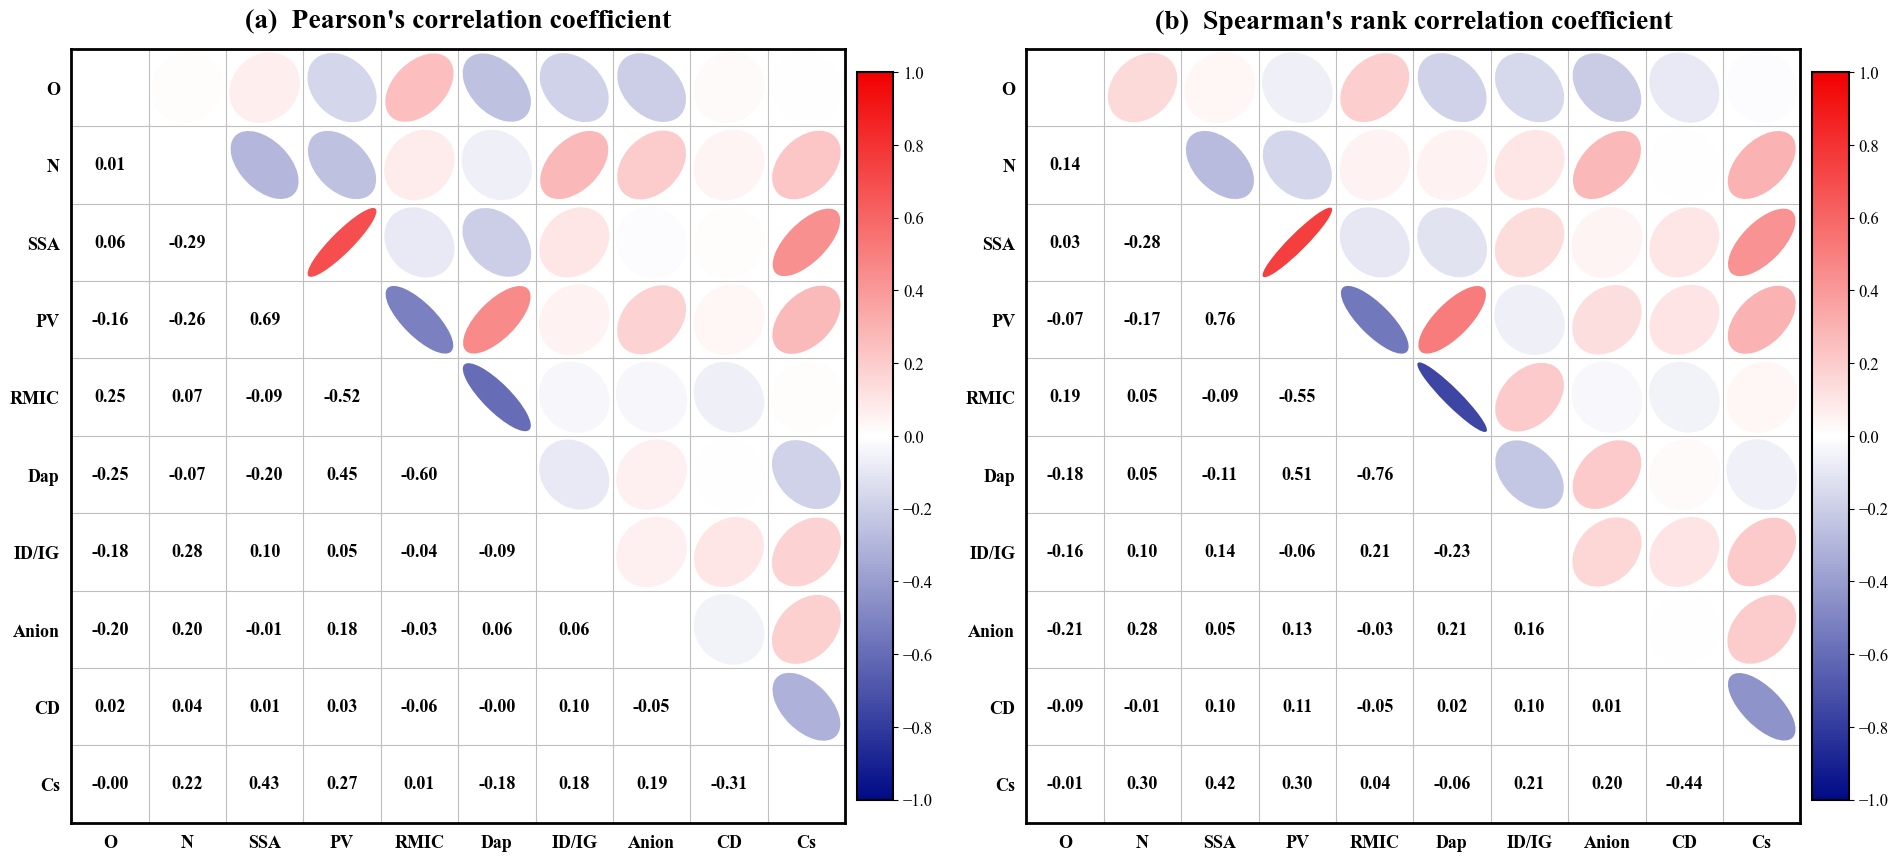

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

data["Anion"] = data["Anion"].replace({
    "SO4": 0,
    "OTf": 1
}).astype(int)

cols = [
    "O", "N", "SSA", "PV", "RMIC",
    "Dap", "ID/IG", "Anion", "CD", "Cs"
]

pearson_corr = data[cols].corr(method="pearson")
spearman_corr = data[cols].corr(method="spearman")

cmap = LinearSegmentedColormap.from_list(
    "paper_cmap",
    ["#000b86", "#ffffff", "#f20000"]
)
norm = Normalize(vmin=-1, vmax=1)

plt.rcParams["font.family"] = "Times New Roman"

def draw_corr(fig, ax, corr, title):
    n = len(cols)

    for i in range(n):
        for j in range(n):
            r = corr.iloc[i, j]

            if i > j:
                ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{r:.2f}",
                    ha="center",
                    va="center",
                    fontsize=13,
                    fontweight="bold"
                )

            elif i < j:
                strength = abs(r)

                major_axis = 0.95 + 0.40 * strength
                minor_axis = 0.90 * (1 - strength)

                ellipse = Ellipse(
                    xy=(j + 0.5, i + 0.5),
                    width=major_axis,
                    height=minor_axis,
                    angle=-45 if r >= 0 else 45,
                    facecolor=cmap(norm(r)),
                    edgecolor="none"
                )
                ax.add_patch(ellipse)

    # 坐标轴
    ax.set_xlim(0, n)
    ax.set_ylim(n, 0)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(n) + 0.5)
    ax.set_yticks(np.arange(n) + 0.5)

    ax.set_xticklabels(
        cols,
        fontsize=13,
        fontweight="bold"
    )
    ax.set_yticklabels(
        cols,
        fontsize=13,
        fontweight="bold"
    )

    ax.tick_params(length=0, pad=8)

    for k in range(n + 1):
        ax.axhline(
            k,
            color="#bfbfbf",
            linewidth=0.8,
            zorder=0
        )
        ax.axvline(
            k,
            color="#bfbfbf",
            linewidth=0.8,
            zorder=0
        )

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.set_title(
        title,
        fontsize=20,
        fontweight="bold",
        pad=15
    )

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        fraction=0.046,
        pad=0.015
    )
    cbar.set_ticks(np.linspace(-1, 1, 11))
    cbar.ax.tick_params(labelsize=12)
    cbar.outline.set_linewidth(1.5)

fig, axes = plt.subplots(
    1, 2,
    figsize=(19, 8.5),
    constrained_layout=True
)

draw_corr(
    fig,
    axes[0],
    pearson_corr,
    "(a)  Pearson's correlation coefficient"
)

draw_corr(
    fig,
    axes[1],
    spearman_corr,
    "(b)  Spearman's rank correlation coefficient"
)

# plt.savefig(
#     "pearson_spearman_correlation.png",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()

In [ ]:
# SHAP Feature Importance Analysis

